In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

COLOR_MALE = "#66b3ff"
COLOR_FEMALE = "#ff9999"

ibm_df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(ibm_df.columns.tolist())

print(ibm_df.head())

sns.color_palette("deep")

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27     

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

# Slide 1

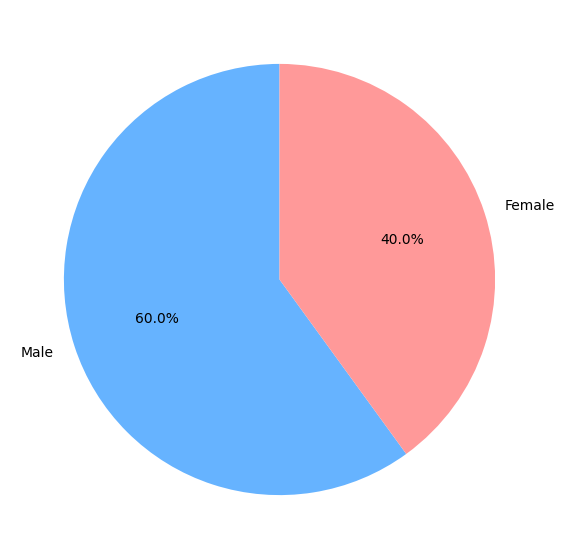

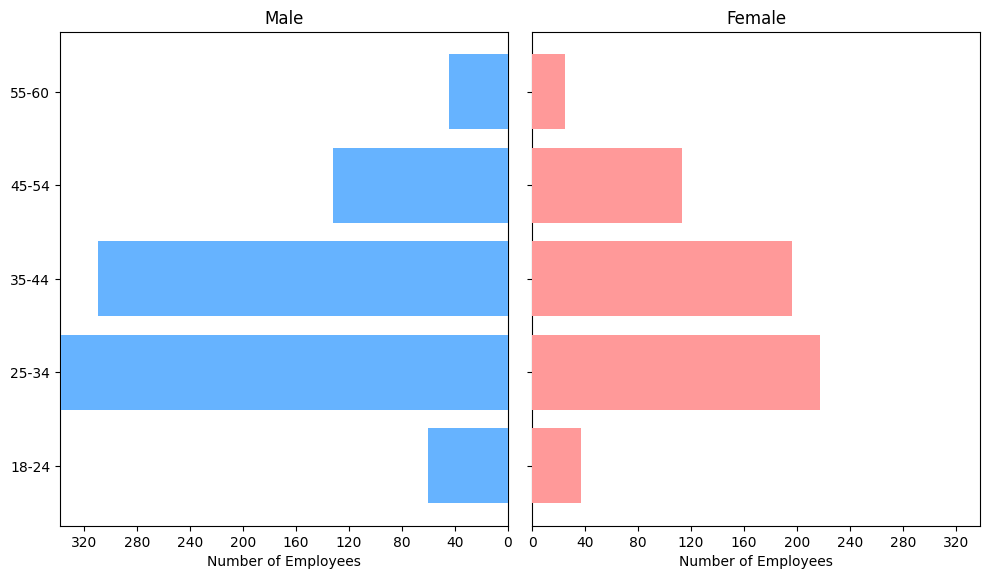

In [21]:
# Slide 2

gender_counts = ibm_df['Gender'].value_counts()

# 1. Pie Chart for Gender Distribution
plt.figure(figsize=(7, 7))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=[COLOR_MALE, COLOR_FEMALE])
plt.title('')
plt.ylabel('') # Hide the y-label
plt.savefig('reports/gender_pie_chart_subset.png')

# 2. Population Pyramid for Age Distribution

# Define new bins and labels for the 18-60 age range
bins = [18, 25, 35, 45, 55, 61]
labels = ['18-24', '25-34', '35-44', '45-54', '55-60']
ibm_df['AgeGroup'] = pd.cut(ibm_df['Age'], bins=bins, labels=labels, right=False)

# Separate data by gender and count age groups
male_counts = ibm_df[ibm_df['Gender'] == 'Male']['AgeGroup'].value_counts().sort_index()
female_counts = ibm_df[ibm_df['Gender'] == 'Female']['AgeGroup'].value_counts().sort_index()

# Reindex to ensure both series have the same age groups, filling missing with 0
all_labels = ibm_df['AgeGroup'].cat.categories
male_counts = male_counts.reindex(all_labels, fill_value=0)
female_counts = female_counts.reindex(all_labels, fill_value=0)

# Create the population pyramid plot
y = np.arange(len(labels))
fig, axes = plt.subplots(ncols=2, sharey=True, figsize=(10, 6))

# Plot male data
axes[0].barh(y, -male_counts, align='center', color='#66b3ff', zorder=10)
axes[0].set(title='Male')
axes[0].set_xlabel('Number of Employees')
max_count = max(male_counts.max(), female_counts.max())
axes[0].set_xlim(left=-max_count-1, right=0)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{abs(int(x))}'))
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Plot female data
axes[1].barh(y, female_counts, align='center', color='#ff9999', zorder=10)
axes[1].set(title='Female')
axes[1].set_xlabel('Number of Employees')
axes[1].set_xlim(left=0, right=max_count+1)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Adjust layout and labels
fig.suptitle('')
plt.yticks(y, labels)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('reports/population_pyramid_subset.png')